In [1]:
# ===================================================
# Fine-Tuning Results Analysis Notebook
# Purpose: Analyze GA fine tuning results
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
import os
import json
import pandas as pd


results_dir = r"C:\Users\57305\Documents\FTZ_model_2.0\Experiment_Pipeline\simple_fine_tuning\results\micro\runs"


records = []


for file in os.listdir(results_dir):
    if file.endswith(".json"):
        file_path = os.path.join(results_dir, file)
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        
        h = data.get("hparams", {})
        m = data.get("metrics", {})
        d = data.get("diagnostics", {})
        meta = data.get("meta", {})

        record = {
            "candidate_id": data.get("candidate_id"),
            "seed": data.get("seed"),
            "algo": data.get("algo"),

            
            "best_final": m.get("best_final"),
            "auc_best": m.get("auc_best"),
            "auc_best_norm": m.get("auc_best_norm"),
            "runtime_sec": m.get("runtime_sec"),
            "evals_total": m.get("evals_total"),
            "budget_triggered": m.get("budget_triggered"),

            
            "delta_abs_best": d.get("best", {}).get("delta_abs"),
            "delta_rel_best": d.get("best", {}).get("delta_rel"),


            "lambda_in": h.get("lambda_in"),
            "lambda_out": h.get("lambda_out"),
            "sel_mutation": h.get("sel_mutation"),
            "tail_mutation": h.get("tail_mutation"),
            "tourn_size": h.get("tourn_size"),
            "popsize": h.get("popsize"),
            "generations": h.get("generations"),

            
            "L_used": meta.get("L_used"),
            "runtime_sec_meta": meta.get("runtime_sec"),
        }

        records.append(record)


df_finetuning = pd.DataFrame(records)


df_finetuning = df_finetuning.sort_values(by=["candidate_id", "seed"]).reset_index(drop=True)


print(f"✅ {len(df_finetuning)} resultados cargados.")
display(df_finetuning.head())


✅ 1100 resultados cargados.


,candidate_id,seed,algo,best_final,auc_best,auc_best_norm,runtime_sec,evals_total,budget_triggered,delta_abs_best,delta_rel_best,lambda_in,lambda_out,sel_mutation,tail_mutation,tourn_size,popsize,generations,L_used,runtime_sec_meta
0,4731,101,micro,438.65,43856.450,438.56450,254.632070,2122,False,1.50,0.003431,0.05,0.2,0.015,0.0075,2.0,22,100,33,254.632070
1,4731,202,micro,438.65,43855.775,438.55775,254.948643,2122,False,1.95,0.004465,0.05,0.2,0.015,0.0075,2.0,22,100,33,254.948643
2,4731,303,micro,438.65,43853.825,438.53825,252.173901,2122,False,1.95,0.004465,0.05,0.2,0.015,0.0075,2.0,22,100,33,252.173901
3,4731,404,micro,438.65,43856.525,438.56525,249.638385,2122,False,1.65,0.003776,0.05,0.2,0.015,0.0075,2.0,22,100,33,249.638385
4,4731,505,micro,438.65,43859.900,438.59900,260.136520,2122,False,1.50,0.003431,0.05,0.2,0.015,0.0075,2.0,22,100,33,260.136520


In [3]:
import pandas as pd
import numpy as np
from scipy.stats import rankdata, kruskal

# Métrica base
metric = "auc_best_norm"


groups = [g[metric].values for _, g in df_finetuning.groupby("candidate_id")]
kruskal_result = kruskal(*groups)

print(f"Kruskal–Wallis H = {kruskal_result.statistic:.3f}, p = {kruskal_result.pvalue:.3e}")


Kruskal–Wallis H = 589.286, p = 8.686e-71


In [4]:
# Añade los ranks globales (rangos de menor a mayor)
df_finetuning["rank"] = rankdata(df_finetuning[metric])

# Promedio de rangos por candidato
rank_means = (
    df_finetuning.groupby("candidate_id")["rank"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)

rank_means["rank_mean_diff"] = rank_means["mean"] - rank_means["mean"].mean()
display(rank_means.head(10))


,mean,std,count,rank_mean_diff
candidate_id,,,,
68799,958.681818,188.512635,11,408.181818
89914,920.363636,137.398706,11,369.863636
74154,919.909091,163.420748,11,369.409091
90935,905.318182,156.159898,11,354.818182
59884,895.863636,172.754463,11,345.363636
9279,895.454545,154.814478,11,344.954545
73739,892.454545,173.217270,11,341.954545
40034,855.136364,203.687640,11,304.636364
21750,848.772727,268.799215,11,298.272727


C:\Users\57305\AppData\Local\Temp\ipykernel_39628\759400793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


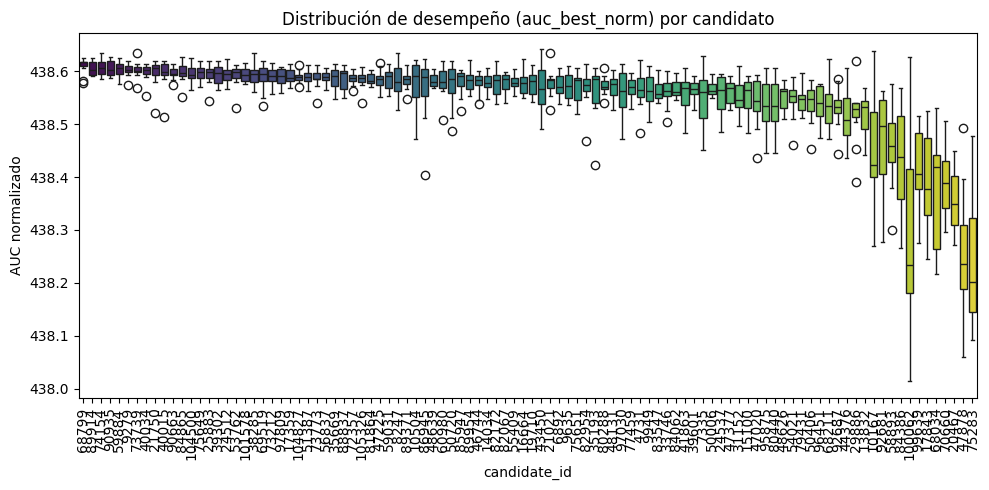

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_finetuning,
    x="candidate_id",
    y="auc_best_norm",
    order=rank_means.index,  # ordenados por rango promedio
    palette="viridis"
)
plt.xticks(rotation=90)
plt.title("Distribución de desempeño (auc_best_norm) por candidato")
plt.ylabel("AUC normalizado")
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
from scipy.stats import mannwhitneyu
import itertools

# --- Filtramos la métrica de interés ---
metric = "auc_best_norm"

# Agrupamos por candidato
groups = {cid: g[metric].values for cid, g in df_finetuning.groupby("candidate_id")}

# Generamos todas las combinaciones de pares (sin repetición)
pairs = list(itertools.combinations(groups.keys(), 2))

# Ejecutamos Mann-Whitney U para cada par (una-sided: "greater" → c1 > c2)
results = []
for c1, c2 in pairs:
    stat, p = mannwhitneyu(groups[c1], groups[c2], alternative="greater")
    results.append({
        "comparison": f"{c1} > {c2}",
        "n_c1": len(groups[c1]),
        "n_c2": len(groups[c2]),
        "statistic": stat,
        "p_value": p
    })

df_wilcoxon = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)

# Aplicamos Bonferroni para corregir comparaciones múltiples
df_wilcoxon["p_adj_bonferroni"] = df_wilcoxon["p_value"] * len(df_wilcoxon)
df_wilcoxon["significant"] = df_wilcoxon["p_adj_bonferroni"] < 0.05

display(df_wilcoxon.head(10))


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,68799 > 96451,11,11,121.0,0.000039,0.191659,False
1,68799 > 75283,11,11,121.0,0.000039,0.192560,False
2,68799 > 92681,11,11,121.0,0.000039,0.192560,False
3,68799 > 99639,11,11,121.0,0.000039,0.192560,False
4,73773 > 99639,11,11,121.0,0.000039,0.192560,False
5,73773 > 75283,11,11,121.0,0.000039,0.192560,False
6,68799 > 70660,11,11,121.0,0.000039,0.192560,False
7,68799 > 84386,11,11,121.0,0.000039,0.192560,False
8,89914 > 92687,11,11,121.0,0.000040,0.196197,False
9,89914 > 96451,11,11,121.0,0.000040,0.196197,False


In [7]:
df_wilcoxon[df_wilcoxon["significant"]]


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant


In [8]:
df_wilcoxon.sort_values("p_value", ascending=True)
df_wilcoxon.sort_values("statistic", ascending=False)

,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,68799 > 96451,11,11,121.0,0.000039,0.191659,False
1,68799 > 75283,11,11,121.0,0.000039,0.192560,False
2,68799 > 92681,11,11,121.0,0.000039,0.192560,False
3,68799 > 99639,11,11,121.0,0.000039,0.192560,False
4,73773 > 99639,11,11,121.0,0.000039,0.192560,False
...,...,...,...,...,...,...,...
4945,47878 > 73773,11,11,0.0,0.999971,4949.854066,False
4946,68034 > 73773,11,11,0.0,0.999971,4949.854066,False
4947,58893 > 68799,11,11,0.0,0.999971,4949.854066,False
4948,70660 > 73773,11,11,0.0,0.999971,4949.854066,False


In [9]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

# --- Parámetros ---
metric = "auc_best_norm"
alpha = 0.05

# --- Construir matriz seed × candidate ---
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

# --- Generar combinaciones de pares ---
candidates = pivot.columns.tolist()
pairs = list(itertools.combinations(candidates, 2))

results = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()  # elimina seeds faltantes
    if len(data) < 5:
        continue  # descarta pares con pocas observaciones

    # Diferencias por seed
    diff = data[c1] - data[c2]

    # Test una-cola: H1 = c1 > c2
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")

    results.append({
        "c1": c1,
        "c2": c2,
        "comparison": f"{c1} > {c2}",
        "n_seeds": len(data),
        "statistic": stat,
        "p_value": p
    })

df_tests = pd.DataFrame(results)

# --- Corrección Holm (recomendada) ---
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=alpha, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# --- Corrección Bonferroni (opcional) ---
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < alpha

# --- Ordenar por evidencia más fuerte ---
df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)

display(df_tests.head(15))


c:\Users\57305\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


,c1,c2,comparison,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,4731,6892,4731 > 6892,11,19.0,0.896973,1.0,False,1.0,False
1,4731,7335,4731 > 7335,11,41.0,0.259766,1.0,False,1.0,False
2,4731,8247,4731 > 8247,11,18.0,0.912598,1.0,False,1.0,False
3,4731,9279,4731 > 9279,11,1.0,0.999512,1.0,False,1.0,False
4,4731,9635,4731 > 9635,11,27.0,0.711426,1.0,False,1.0,False
5,4731,9949,4731 > 9949,11,38.0,0.342285,1.0,False,1.0,False
6,4731,10167,4731 > 10167,11,59.0,0.009277,1.0,False,1.0,False
7,4731,10504,4731 > 10504,11,28.0,0.666016,1.0,False,1.0,False
8,4731,13832,4731 > 13832,11,59.0,0.009277,1.0,False,1.0,False
9,4731,14034,4731 > 14034,11,20.0,0.879883,1.0,False,1.0,False


In [10]:
df_tests[df_tests["significant_holm"]]


,c1,c2,comparison,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf


In [11]:
# df_tests debe provenir del bloque anterior (Wilcoxon pareado)
# Columnas requeridas: c1, c2, significant_holm

# Inicializamos contadores
candidates = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=candidates, columns=["wins", "losses"], data=0)

for _, row in df_tests.iterrows():
    c1, c2 = row["c1"], row["c2"]
    if row["significant_holm"]:  # c1 > c2 con significancia
        summary.loc[c1, "wins"] += 1
        summary.loc[c2, "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary = summary.sort_values("net_wins", ascending=False)

display(summary)


,wins,losses,net_wins
4731,0,0,0
6892,0,0,0
7335,0,0,0
8247,0,0,0
9279,0,0,0
...,...,...,...
100062,0,0,0
101578,0,0,0
104500,0,0,0
104827,0,0,0


# Candidatos

In [12]:
import numpy as np
import pandas as pd

# Cálculo del LCB95
g = df_finetuning.groupby("candidate_id")["auc_best_norm"]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# n=11 → df=10 → t_{0.95,10} ≈ 1.812 (unilateral 95%)
tcrit = 1.812
lcb95 = mean - tcrit * se

# Tabla ordenada únicamente por desempeño robusto
df_lcb = (
    pd.DataFrame({"auc_mean": mean, "auc_std": std, "lcb95": lcb95})
    .sort_values("lcb95", ascending=False)
)

# Elige top K para test pareado
top = 10
short_candidates = df_lcb.head(top).index.tolist()

df_lcb.head(10), short_candidates


(                auc_mean   auc_std       lcb95
 candidate_id                                  
 68799         438.610659  0.015730  438.602065
 89914         438.606295  0.013060  438.599160
 74154         438.607250  0.015736  438.598653
 90935         438.605477  0.014767  438.597410
 9279          438.602886  0.012589  438.596008
 59884         438.603977  0.014759  438.595914
 73739         438.603432  0.016164  438.594601
 90663         438.597295  0.011385  438.591076
 40034         438.598932  0.017378  438.589437
 104500        438.597432  0.017469  438.587888,
 [68799, 89914, 74154, 90935, 9279, 59884, 73739, 90663, 40034, 104500])

In [13]:
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

metric = "auc_best_norm"
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

pairs = list(itertools.combinations(short_candidates, 2))
rows = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5:
        continue
    diff = data[c1] - data[c2]  # pareado por seed
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(data), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

# Corrección Holm dentro del shortlist (mucho menos comparaciones)
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# Bonferroni opcional (clip 1.0)
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < 0.05

df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)
df_tests.head(20)


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,68799,90663,11,62.0,0.003418,0.153809,False,0.153809,False
1,68799,40034,11,59.5,0.007324,0.322266,False,0.329590,False
2,68799,104500,11,59.5,0.007812,0.335938,False,0.351562,False
3,90935,90663,11,57.0,0.016113,0.676758,False,0.725098,False
4,68799,9279,11,55.5,0.020508,0.840820,False,0.922852,False
5,74154,90663,11,55.5,0.021973,0.878906,False,0.988770,False
6,89914,90663,11,55.0,0.022461,0.878906,False,1.000000,False
7,68799,73739,11,51.0,0.058105,1.000000,False,1.000000,False
8,68799,59884,11,49.5,0.070312,1.000000,False,1.000000,False
9,89914,104500,11,49.5,0.077637,1.000000,False,1.000000,False


In [14]:
# Resumen de victorias/derrotas usando Holm
cands = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=cands, columns=["wins","losses"], data=0)

for _, row in df_tests.iterrows():
    if row["significant_holm"]:
        summary.loc[row["c1"], "wins"]  += 1
        summary.loc[row["c2"], "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary["win_rate"] = summary["wins"] / (summary["wins"] + summary["losses"] + 1e-9)
summary = summary.sort_values(["win_rate","net_wins","wins"], ascending=[False, False, False])

summary


,wins,losses,net_wins,win_rate
9279,0,0,0,0.0
40034,0,0,0,0.0
59884,0,0,0,0.0
68799,0,0,0,0.0
73739,0,0,0,0.0
74154,0,0,0,0.0
89914,0,0,0,0.0
90663,0,0,0,0.0
90935,0,0,0,0.0
104500,0,0,0,0.0


In [15]:
import numpy as np
import pandas as pd
from scipy.stats import t

metric = "auc_best_norm"
top = 10  # tamaño del shortlist

g = df_finetuning.groupby("candidate_id")[metric]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# t crítico unil. 95% por candidato (por si algún n != 11)
tcrit = t.ppf(1 - 0.05, df=(n - 1).clip(lower=1))
lcb95 = mean - tcrit * se
p10   = g.quantile(0.10)

df_lcb = (pd.DataFrame({
    "auc_mean": mean, "auc_std": std, "n": n, "se": se, "lcb95": lcb95, "p10": p10
}).sort_values(["lcb95","p10","auc_mean"], ascending=[False, False, False]))

short_candidates = df_lcb.head(top).index.tolist()
display(df_lcb.head(top))
print("Shortlist:", short_candidates)


,auc_mean,auc_std,n,se,lcb95,p10
candidate_id,,,,,,
68799,438.610659,0.015730,11,0.004743,438.602063,438.58175
89914,438.606295,0.013060,11,0.003938,438.599159,438.59225
74154,438.607250,0.015736,11,0.004744,438.598651,438.58775
90935,438.605477,0.014767,11,0.004452,438.597408,438.58925
9279,438.602886,0.012589,11,0.003796,438.596007,438.59375
59884,438.603977,0.014759,11,0.004450,438.595912,438.58850
73739,438.603432,0.016164,11,0.004874,438.594599,438.59375
90663,438.597295,0.011385,11,0.003433,438.591074,438.58475
40034,438.598932,0.017378,11,0.005240,438.589435,438.58925


Shortlist: [68799, 89914, 74154, 90935, 9279, 59884, 73739, 90663, 40034, 104500]


In [16]:
import itertools
from scipy.stats import wilcoxon

pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

rows = []
for c1, c2 in itertools.combinations(short_candidates, 2):
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5: 
        continue
    d = data[c1] - data[c2]
    stat, p = wilcoxon(d, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(d), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

from statsmodels.stats.multitest import multipletests
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

display(df_tests.head(20))

# Tamaño de efecto (Cliff’s delta)
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    gt = sum((xi > yi) for xi in x for yi in y)
    lt = sum((xi < yi) for xi in x for yi in y)
    return (gt - lt) / (len(x) * len(y))

effects = []
for _, r in df_tests.iterrows():
    x = df_finetuning.loc[df_finetuning["candidate_id"]==r["c1"], metric].values
    y = df_finetuning.loc[df_finetuning["candidate_id"]==r["c2"], metric].values
    effects.append({"c1": r["c1"], "c2": r["c2"], "cliffs_delta": cliffs_delta(x, y)})

df_effects = pd.DataFrame(effects).sort_values("cliffs_delta", ascending=False)
display(df_effects.head(20))


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm
0,68799,90663,11,62.0,0.003418,0.153809,False
1,68799,40034,11,59.5,0.007324,0.322266,False
2,68799,104500,11,59.5,0.007812,0.335938,False
3,90935,90663,11,57.0,0.016113,0.676758,False
4,68799,9279,11,55.5,0.020508,0.840820,False
5,74154,90663,11,55.5,0.021973,0.878906,False
6,89914,90663,11,55.0,0.022461,0.878906,False
7,68799,73739,11,51.0,0.058105,1.000000,False
8,68799,59884,11,49.5,0.070312,1.000000,False
9,89914,104500,11,49.5,0.077637,1.000000,False


,c1,c2,cliffs_delta
0,68799,90663,0.611570
1,68799,40034,0.586777
4,68799,9279,0.438017
7,68799,73739,0.438017
5,74154,90663,0.404959
2,68799,104500,0.396694
8,68799,59884,0.355372
16,73739,90663,0.330579
6,89914,90663,0.305785
20,9279,90663,0.297521


In [17]:
from scipy.stats import wilcoxon

def noninferiority_paired(d, Delta):
    # H0: mu_d <= -Delta  vs  H1: mu_d > -Delta
    # Testea d + Delta > 0 (una cola)
    stat, p = wilcoxon(d + Delta, alternative="greater", zero_method="pratt")
    return p

def nosuperiority_paired(d, Delta):
    # H0: mu_d >=  Delta  vs  H1: mu_d <  Delta
    # Testea -(d - Delta) > 0  => Delta - d > 0  (una cola)
    stat, p = wilcoxon(Delta - d, alternative="greater", zero_method="pratt")
    return p

Delta = 0.010  # margen práctico; ajusta a tu unidad

champion = short_candidates[0]  # top por LCB95
pivot_short = pivot[short_candidates].dropna()
tost_rows = []
for c in short_candidates[1:]:
    d = (pivot_short[champion] - pivot_short[c]).dropna()
    if len(d) < 5:
        continue
    p_noninf = noninferiority_paired(d, Delta)
    p_nosup = nosuperiority_paired(d, Delta)
    # Equivalencia si ambas p < alpha
    tost_rows.append({"champion": champion, "challenger": c,
                      "n_seeds": len(d),
                      "p_noninferior": p_noninf, "p_nosuperior": p_nosup,
                      "equivalent_(TOST)": (p_noninf < 0.05) and (p_nosup < 0.05)})

df_tost = pd.DataFrame(tost_rows).sort_values(["equivalent_(TOST)","p_noninferior","p_nosuperior"],
                                              ascending=[False, True, True])
display(df_tost)


,champion,challenger,n_seeds,p_noninferior,p_nosuperior,equivalent_(TOST)
1,68799,74154,11,0.001465,0.048828,True
8,68799,104500,11,0.000488,0.732910,False
6,68799,90663,11,0.000488,0.834473,False
7,68799,40034,11,0.000977,0.732422,False
4,68799,59884,11,0.001465,0.206543,False
3,68799,9279,11,0.001465,0.312012,False
5,68799,73739,11,0.002441,0.200195,False
0,68799,89914,11,0.012207,0.155273,False
2,68799,90935,11,0.026855,0.259766,False


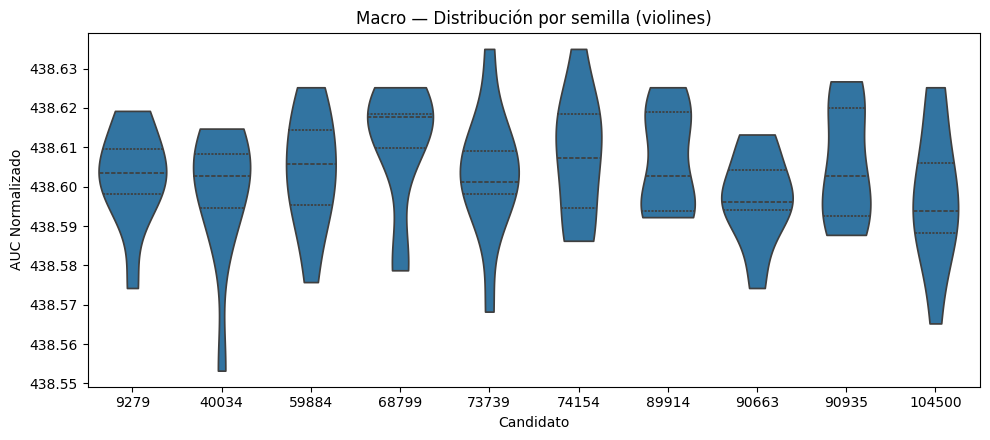

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = [68799, 89914, 74154, 90935, 9279, 59884, 73739, 90663, 40034, 104500]
subset = df_finetuning[df_finetuning["candidate_id"].isin(top10)]

plt.figure(figsize=(10,4.5))
sns.violinplot(data=subset, x="candidate_id", y="auc_best_norm",
               inner="quartile", cut=0)
plt.title("Macro — Distribución por semilla (violines)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.tight_layout()
plt.show()

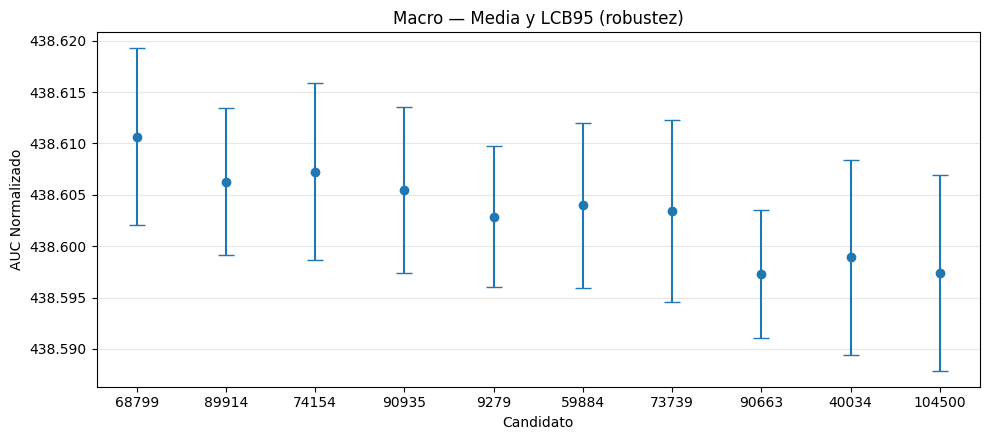

In [21]:
import numpy as np
import matplotlib.pyplot as plt

df_plot = df_lcb.loc[top10, ["auc_mean","lcb95"]].copy()
df_plot["yerr_down"] = df_plot["auc_mean"] - df_plot["lcb95"]

plt.figure(figsize=(10,4.5))
plt.errorbar(df_plot.index.astype(str),
             df_plot["auc_mean"],
             yerr=df_plot["yerr_down"],
             fmt='o', capsize=6)
plt.title("Macro — Media y LCB95 (robustez)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

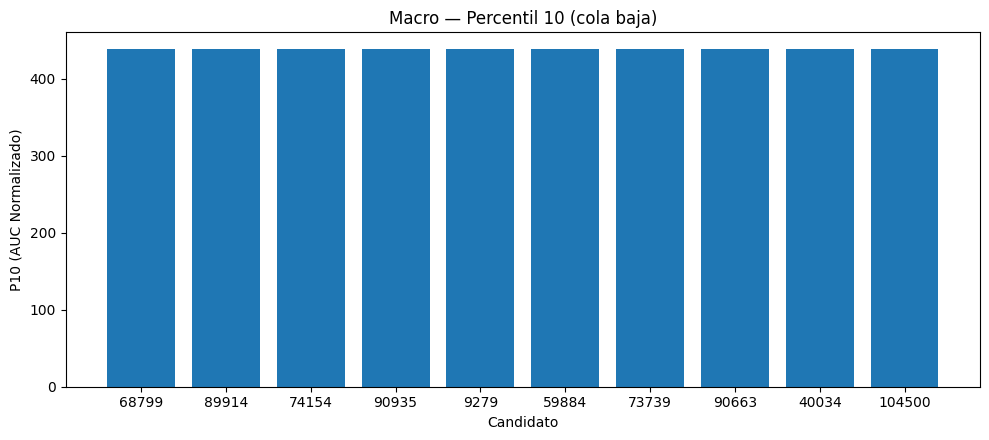

In [22]:
import matplotlib.pyplot as plt

p10_plot = df_lcb.loc[top10, "p10"]

plt.figure(figsize=(10,4.5))
plt.bar(p10_plot.index.astype(str), p10_plot.values)
plt.title("Macro — Percentil 10 (cola baja)")
plt.xlabel("Candidato")
plt.ylabel("P10 (AUC Normalizado)")
plt.tight_layout()
plt.show()


In [27]:
winner = 68799
report = (
    df_lcb.loc[top10, ["auc_mean","auc_std","n","se","lcb95","p10"]]
      .sort_values("lcb95", ascending=False)
)
print("WINNER (robustez):", winner)
display(report)

WINNER (robustez): 68799


,auc_mean,auc_std,n,se,lcb95,p10
candidate_id,,,,,,
68799,438.610659,0.015730,11,0.004743,438.602063,438.58175
89914,438.606295,0.013060,11,0.003938,438.599159,438.59225
74154,438.607250,0.015736,11,0.004744,438.598651,438.58775
90935,438.605477,0.014767,11,0.004452,438.597408,438.58925
9279,438.602886,0.012589,11,0.003796,438.596007,438.59375
59884,438.603977,0.014759,11,0.004450,438.595912,438.58850
73739,438.603432,0.016164,11,0.004874,438.594599,438.59375
90663,438.597295,0.011385,11,0.003433,438.591074,438.58475
40034,438.598932,0.017378,11,0.005240,438.589435,438.58925


In [28]:
cid = 68799

params_68799 = (
    df_finetuning
    .loc[df_finetuning["candidate_id"] == cid, ["lambda_in","lambda_out","sel_mutation", "tail_mutation", "tourn_size"]]
    .iloc[0]
)

params_68799

lambda_in        0.40
lambda_out       0.30
sel_mutation     0.02
tail_mutation    0.02
tourn_size       5.00
Name: 627, dtype: float64